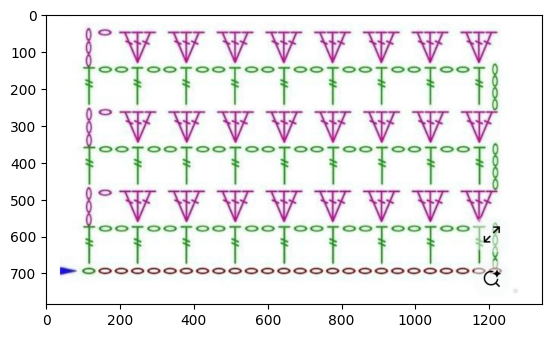

In [13]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import math


IMG_PATH = "data/raw/easy/45.png"
img = cv.imread(IMG_PATH)
plt.imshow(img)

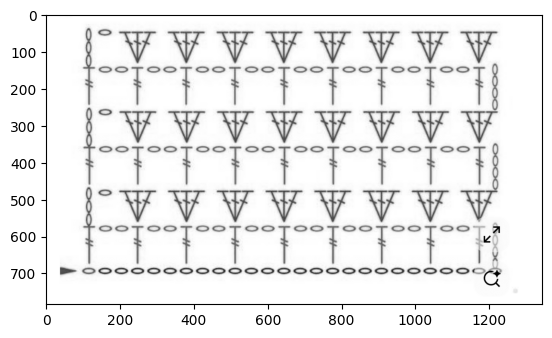

In [14]:
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
plt.imshow(gray_img, cmap='gray')

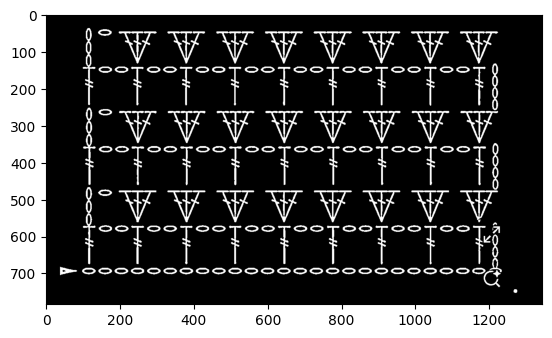

In [15]:
denoised = cv.fastNlMeansDenoising(gray_img, h=10, templateWindowSize=7,
                                         searchWindowSize=21)

thresh = cv.adaptiveThreshold(
        denoised, 255,
        cv.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv.THRESH_BINARY_INV,
        blockSize=19, C=4
    )
plt.imshow(thresh, cmap='gray')

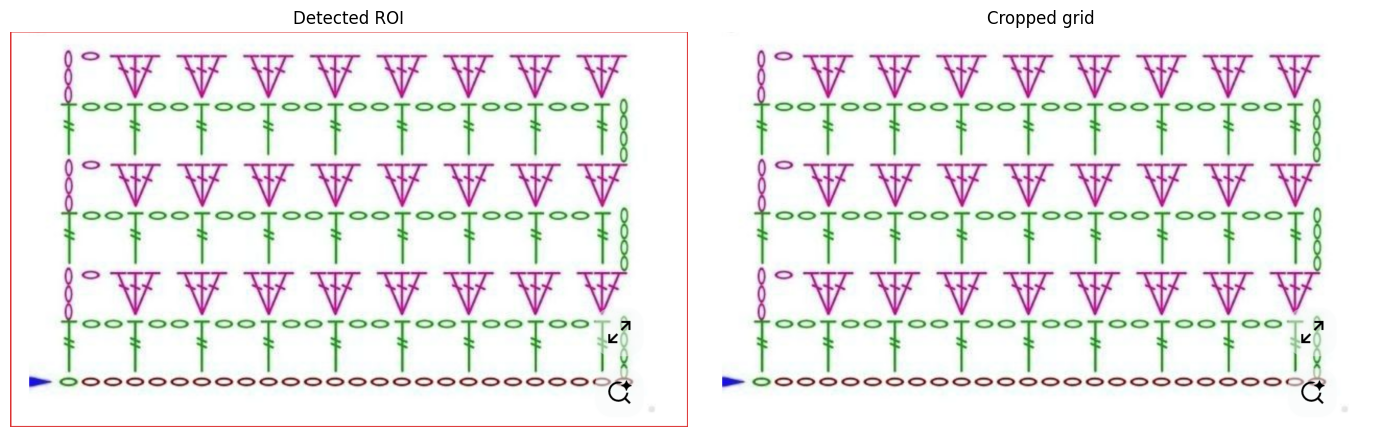

ROI: (0, 0, 1344, 784)


In [16]:
def find_stitch_roi(binary: np.ndarray,
                    min_fill_ratio: float = 0.05,
                    margin_frac: float = 0.02) -> tuple[int,int,int,int]:
    """
    Locate the bounding box of the densest connected region (the stitch grid).
    Returns (x, y, w, h) in pixel coordinates.

    Strategy
    --------
    1. Dilate heavily so nearby symbols merge into blobs.
    2. Find the largest blob by area — that is the stitch grid.
    3. Return its bounding rectangle with a small margin.
    """
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (2, 2))
    cleaned = cv.morphologyEx(binary, cv.MORPH_OPEN, kernel, iterations=1)

    # 4. Close small gaps inside symbols
    kernel2 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
    closed = cv.morphologyEx(cleaned, cv.MORPH_CLOSE, kernel2, iterations=1)


    # Dilate so all stitch symbols within a piece connect
    k = cv.getStructuringElement(cv.MORPH_RECT, (30, 20))
    dilated = cv.dilate(closed, k, iterations=3)
    
    # Find contours of merged blobs
    contours, _ = cv.findContours(dilated, cv.RETR_EXTERNAL,
                                    cv.CHAIN_APPROX_SIMPLE)
    if not contours:
        h, w = closed.shape
        return 0, 0, w, h

    # Pick the largest contour
    largest = max(contours, key=cv.contourArea)
    x, y, w, h = cv.boundingRect(largest)

    # Add margin
    H, W = closed.shape
    mx = int(W * margin_frac)
    my = int(H * margin_frac)
    x = max(0, x - mx);  y = max(0, y - my)
    w = min(W - x, w + 2*mx)
    h = min(H - y, h + 2*my)
    return x, y, w, h


def crop_roi(img_rgb, binary, roi):
    x, y, w, h = roi
    return img_rgb[y:y+h, x:x+w], binary[y:y+h, x:x+w]


roi = find_stitch_roi(thresh)
roi_rgb, roi_bin = crop_roi(img, thresh, roi)

# Visualise
vis = img.copy()
x,y,w,h = roi
cv.rectangle(vis, (x,y), (x+w,y+h), (220,50,50), 4)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(vis);     axes[0].set_title('Detected ROI'); axes[0].axis('off')
axes[1].imshow(roi_rgb); axes[1].set_title('Cropped grid'); axes[1].axis('off')
plt.tight_layout(); plt.show()
print(f'ROI: {roi}')

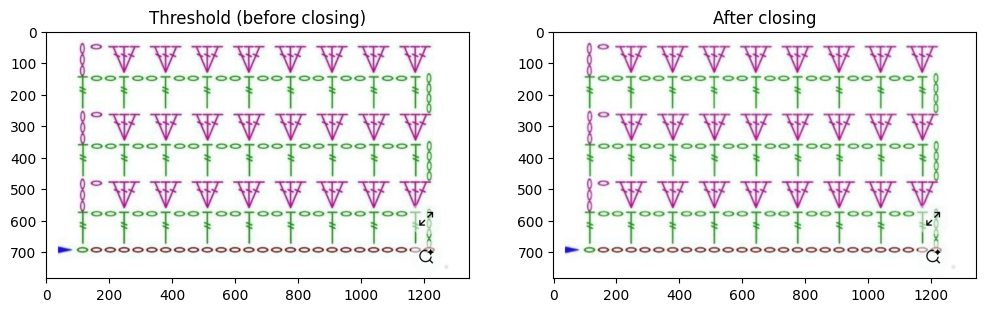

In [17]:
# Close small gaps in broken circle outlines
# Now closing expands white symbol lines to bridge gaps, not the background
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
closed = cv.morphologyEx(roi_rgb, cv.MORPH_CLOSE, kernel)

# Compare before and after
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(roi_rgb, cmap='gray'); ax1.set_title('Threshold (before closing)')
ax2.imshow(closed, cmap='gray');    ax2.set_title('After closing')
plt.show()

In [18]:
contours, hierarchy = cv.findContours(roi_bin, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Filter out nested contours: if a bounding box is completely inside another, keep only the outer one
def is_inside(rect1, rect2):
    """Check if rect1 is completely inside rect2"""
    x1, y1, w1, h1 = rect1
    x2, y2, w2, h2 = rect2
    return x1 >= x2 and y1 >= y2 and x1 + w1 <= x2 + w2 and y1 + h1 <= y2 + h2

bounding_rects = [cv.boundingRect(c) for c in contours]
# Sort by area descending
sorted_indices = sorted(range(len(bounding_rects)), key=lambda i: bounding_rects[i][2] * bounding_rects[i][3], reverse=True)
filtered_indices = []
for i in sorted_indices:
    rect = bounding_rects[i]
    is_nested = False
    for j in filtered_indices:
        existing_rect = bounding_rects[j]
        if is_inside(rect, existing_rect):
            is_nested = True
            break
    if not is_nested:
        filtered_indices.append(i)

contours = [contours[i] for i in filtered_indices]

# Draw contours on the original image
img_contours = roi_rgb.copy()

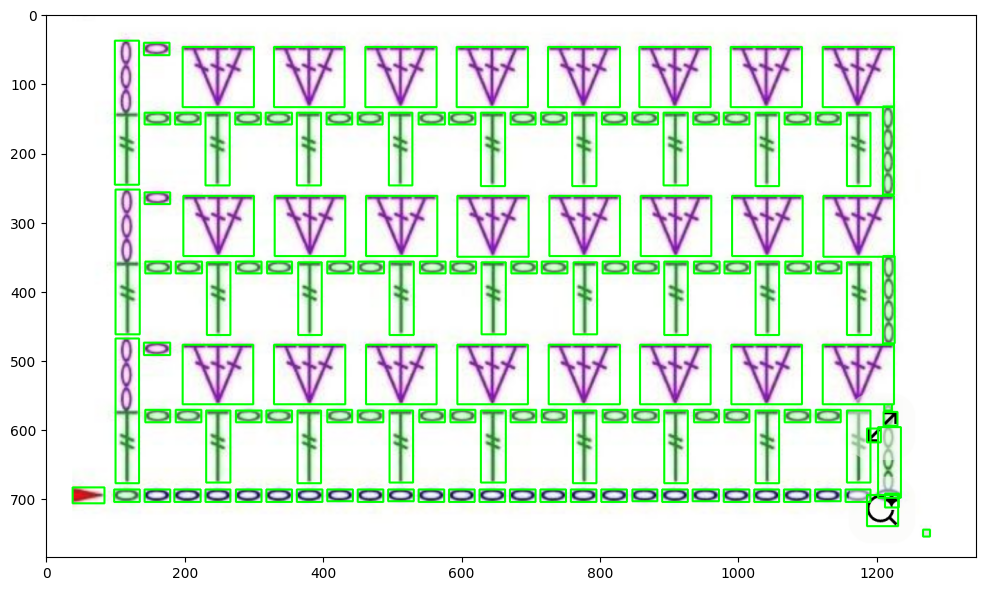

In [19]:
img_vis = roi_rgb.copy()
for c in contours:
    x, y, w, h = cv.boundingRect(c)
    cv.rectangle(img_vis, (x, y), (x+w, y+h), (0, 255, 0), 2)
    
plt.figure(figsize=(12, 12))
plt.imshow(cv.cvtColor(img_vis, cv.COLOR_BGR2RGB))
plt.show()

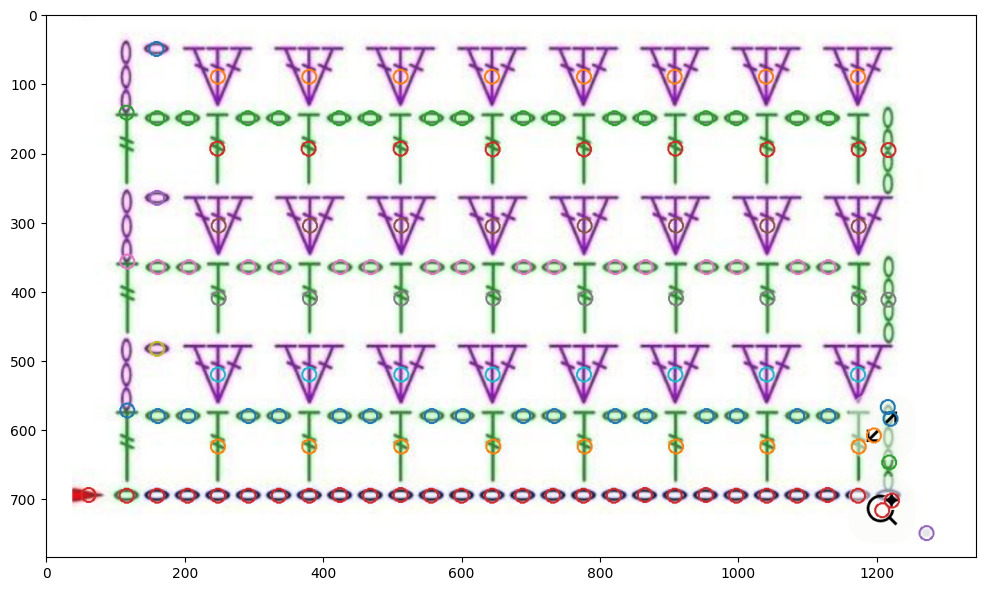

In [20]:
# Cluster contours by their vertical position to group them into rows
contour_centers = [cv.boundingRect(c) for c in contours]
contour_centers = [(x + w/2, y + h/2) for x, y, w, h in contour_centers]
contour_centers = sorted(contour_centers, key=lambda c: c[1])
row_groups = []
current_row = []
row_threshold = 20  # pixels
for center in contour_centers:
    if not current_row:
        current_row.append(center)
    else:
        _, last_y = current_row[-1]
        _, y = center
        if abs(y - last_y) < row_threshold:
            current_row.append(center)
        else:
            row_groups.append(current_row)
            current_row = [center]
if current_row:
    row_groups.append(current_row)  

# Visualisation
colors = plt.cm.tab10.colors
overlay = cv.cvtColor(roi_rgb.copy(), cv.COLOR_BGR2RGB)
for row_idx, group in enumerate(row_groups):
    color_bgr = tuple(int(c * 255) for c in colors[row_idx % len(colors)][:3])
    for center in group:
        x, y = int(center[0]), int(center[1])
        cv.circle(overlay, (x, y), 10, color_bgr, 2)

plt.figure(figsize=(12, 12))
plt.imshow(overlay)
plt.show()

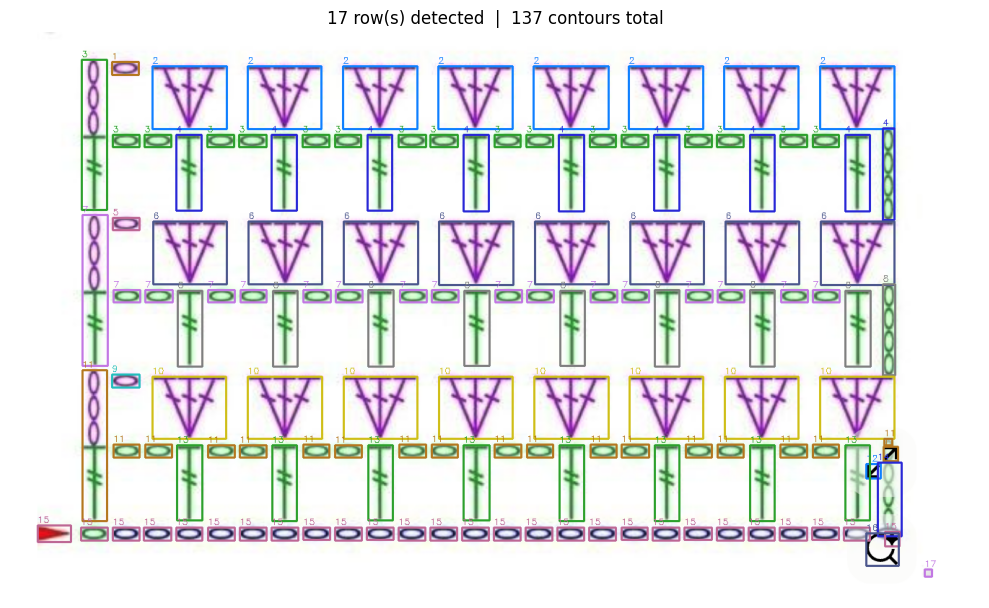

  Row 1: 1 symbol(s)
  Row 2: 8 symbol(s)
  Row 3: 17 symbol(s)
  Row 4: 9 symbol(s)
  Row 5: 1 symbol(s)
  Row 6: 8 symbol(s)
  Row 7: 17 symbol(s)
  Row 8: 9 symbol(s)
  Row 9: 1 symbol(s)
  Row 10: 8 symbol(s)
  Row 11: 19 symbol(s)
  Row 12: 1 symbol(s)
  Row 13: 8 symbol(s)
  Row 14: 1 symbol(s)
  Row 15: 27 symbol(s)
  Row 16: 1 symbol(s)
  Row 17: 1 symbol(s)

Granny square rows detected: 17


In [21]:
def count_rows_from_contours(contours, gap_factor=0.5):
    """
    Count stitch rows by clustering contour bounding boxes by their y-position.

    Contours belonging to the same row have similar y-centres.
    A gap larger than gap_factor * median_height between consecutive
    y-centres means we've crossed into a new row.

    Args:
        contours:    list of OpenCV contours
        gap_factor:  gap threshold as a fraction of the median symbol height.
                     Increase if rows are being merged; decrease if one row
                     is being split into multiple.

    Returns:
        n_rows:      number of detected rows
        row_groups:  list of lists — each inner list holds the contour indices
                     belonging to that row, top to bottom
    """
    if not contours:
        return 0, []

    # Collect (y_centre, height, original_index) for every contour
    boxes = []
    for i, c in enumerate(contours):
        x, y, w, h = cv.boundingRect(c)
        y_centre = y + h / 2
        boxes.append((y_centre, h, i))

    # Sort by y_centre top → bottom
    boxes.sort(key=lambda b: b[0])
    y_centres = np.array([b[0] for b in boxes])
    heights   = np.array([b[1] for b in boxes])

    median_h  = np.median(heights)
    min_gap   = gap_factor * median_h

    # Gap-based clustering: a jump larger than min_gap starts a new row
    row_groups = []
    current_row = [boxes[0][2]]

    for i in range(1, len(boxes)):
        gap = y_centres[i] - y_centres[i - 1]
        if gap > min_gap:
            row_groups.append(current_row)
            current_row = []
        current_row.append(boxes[i][2])
    row_groups.append(current_row)

    n_rows = len(row_groups)

    # ── Visualisation ────────────────────────────────────────────────
    colors = plt.cm.tab10.colors
    overlay = cv.cvtColor(roi_rgb.copy(), cv.COLOR_BGR2RGB)

    for row_idx, group in enumerate(row_groups):
        color_bgr = tuple(int(c * 255) for c in colors[row_idx % len(colors)][:3])
        for ci in group:
            x, y, w, h = cv.boundingRect(contours[ci])
            cv.rectangle(overlay, (x, y), (x + w, y + h), color_bgr[::-1], 2)
            cv.putText(overlay, str(row_idx + 1), (x, y - 4),
                       cv.FONT_HERSHEY_SIMPLEX, 0.4, color_bgr[::-1], 1)

    plt.figure(figsize=(10, 10))
    plt.imshow(overlay)
    plt.title(f"{n_rows} row(s) detected  |  {len(contours)} contours total")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    for i, group in enumerate(row_groups):
        print(f"  Row {i + 1}: {len(group)} symbol(s)")

    return n_rows, row_groups


n_rows, row_groups = count_rows_from_contours(contours)
print(f"\nGranny square rows detected: {n_rows}")

In [22]:
# TODO maybe worth it, but it distorts the chain stich circles, they are hard to recognize 
def center_weighted_crop(crop):
    h, w = crop.shape[:2]
    Y, X = np.ogrid[:h, :w]
    cy, cx = h / 2, w / 2
    sigma = min(h, w) * 0.4
    mask = np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))
    mask = (mask / mask.max()).astype(np.float32)
    if len(crop.shape) == 3:
        mask = mask[:, :, np.newaxis]
    return (crop.astype(np.float32) * mask).astype(np.uint8)

Total symbols: 137


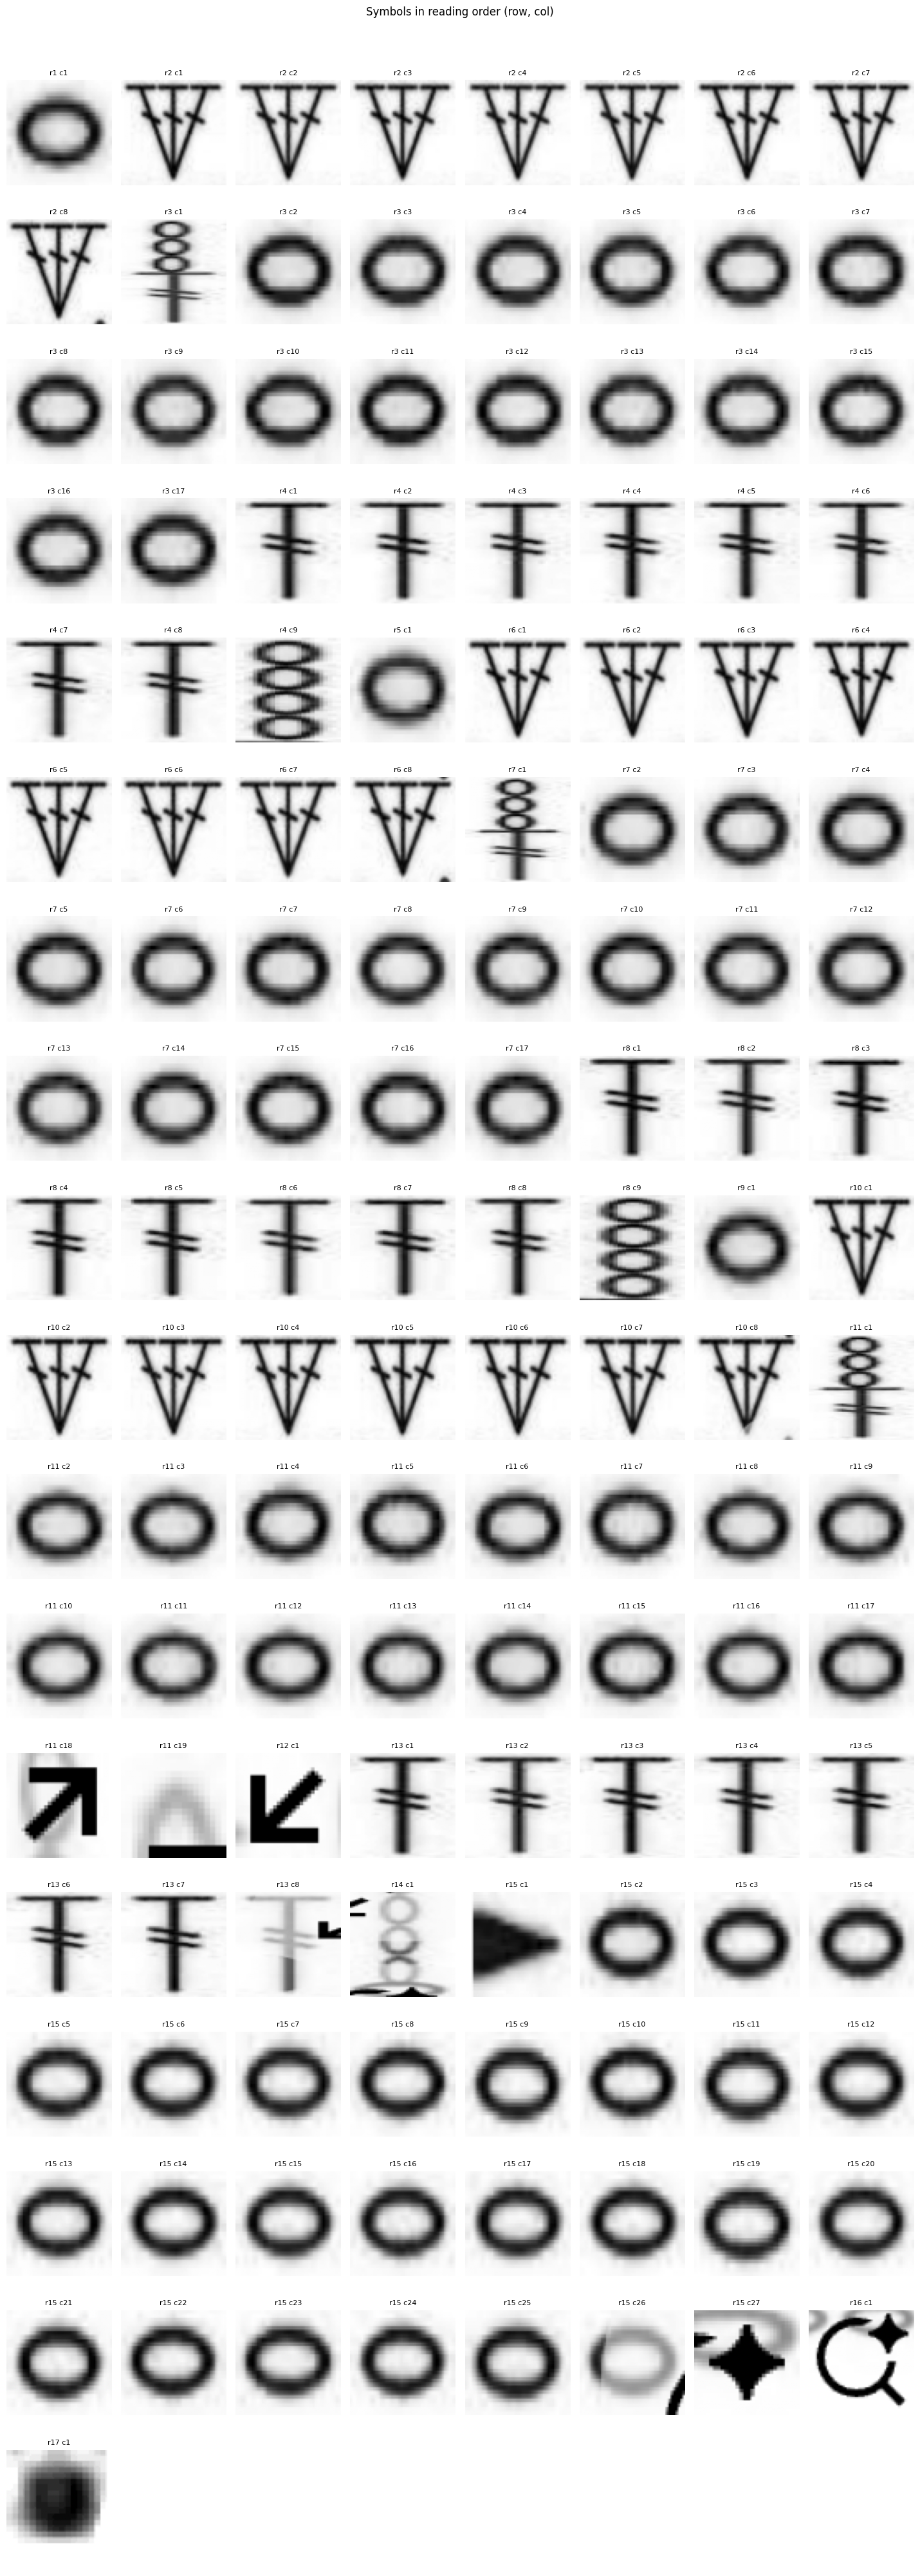

In [23]:
from dataclasses import dataclass

@dataclass
class SymbolCrop:
    image: np.ndarray        # grayscale crop
    row: int                 # 1-based row index (top = 1)
    col: int                 # 1-based position within the row (left = 1)
    bbox: tuple              # (x, y, w, h) in original image coordinates


def iter_symbols(gray, contours, row_groups, padding=4):
    """
    Yield SymbolCrop objects in reading order: top row first,
    left to right within each row.

    Args:
        gray:        grayscale source image to crop from
        contours:    list of OpenCV contours (output of findContours)
        row_groups:  list of lists of contour indices, grouped by row
                     (output of count_rows_from_contours)
        padding:     px of padding added around each bounding box

    Yields:
        SymbolCrop, one per detected symbol in order
    """
    h_img, w_img = gray.shape

    for row_idx, group in enumerate(row_groups):
        # Sort contours within the row left → right by x of bounding box
        sorted_group = sorted(group, key=lambda ci: cv.boundingRect(contours[ci])[0])

        for col_idx, ci in enumerate(sorted_group):
            x, y, w, h = cv.boundingRect(contours[ci])

            # Apply padding, clamped to image bounds
            x1 = max(x - padding, 0)
            y1 = max(y - padding, 0)
            x2 = min(x + w + padding, w_img)
            y2 = min(y + h + padding, h_img)

            crop = gray[y1:y2, x1:x2]
            crop = cv.resize(crop, (64, 64), interpolation=cv.INTER_AREA)

            yield SymbolCrop(
                image=crop,
                row=row_idx + 1,
                col=col_idx + 1,
                bbox=(x, y, w, h),
            )


# ── Quick visual check ────────────────────────────────────────────────────────
roi_gray = cv.cvtColor(roi_rgb.copy(), cv.COLOR_BGR2GRAY)
symbols = list(iter_symbols(roi_gray, contours, row_groups))
print(f"Total symbols: {len(symbols)}")

# Show all crops in a grid, labelled by (row, col)
cols = 8
rows_grid = max(1, (len(symbols) + cols - 1) // cols)
fig, axes = plt.subplots(rows_grid, cols, figsize=(cols * 1.8, rows_grid * 2.2))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for ax, sym in zip(axes, symbols):
    ax.imshow(sym.image, cmap='gray')
    ax.set_title(f"r{sym.row} c{sym.col}", fontsize=8)
    ax.axis('off')
for ax in axes[len(symbols):]:
    ax.axis('off')

plt.suptitle("Symbols in reading order (row, col)", y=1.01)
plt.tight_layout()
plt.show()

In [24]:
# ── Load MobileNetV2 classifier (replaces old HOG+SVM model.joblib) ───────
import sys, joblib, torch, torch.nn as nn
from torchvision import models, transforms
from torchvision.models import MobileNet_V2_Weights
from PIL import Image as _PIL_Image

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


# ── Model definition (must match baseline_ml.ipynb exactly) ───────────────
class StitchMobileNet(nn.Module):
    def __init__(self, n_classes: int, dropout: float = 0.40):
        super().__init__()
        backbone = models.mobilenet_v2(weights=None)
        for p in backbone.parameters():
            p.requires_grad = False
        self.features   = backbone.features
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1280, 256),
            nn.GELU(),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.classifier(x)


# ── Drop-in wrapper with the same interface as the old SymbolClassifier ───
class MobileNetClassifier:
    """
    Wraps StitchMobileNet so the rest of the notebook can call:
        clf.predict(gray_crop_64x64)   → label string
        clf.predict_proba(gray_crop)   → {label: probability, …}
    """
    _TF = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                              [0.229, 0.224, 0.225]),
    ])

    def __init__(self, model, classes):
        self.model   = model.eval()
        self.classes = classes          # list[str], same order as model outputs

    @classmethod
    def load(cls, pt_path: str = 'mobilenet_model.pt'):
        ckpt  = torch.load(pt_path, map_location='cpu', weights_only=False)
        model = StitchMobileNet(ckpt['n_classes'])
        model.load_state_dict(ckpt['model_state'])
        return cls(model, ckpt['classes'])

    def _preprocess(self, gray: 'np.ndarray') -> 'torch.Tensor':
        """Grayscale numpy (any size) → normalised 3-ch tensor (1,3,224,224)."""
        img = cv.resize(gray, (224, 224))
        img = cv.cvtColor(img, cv.COLOR_GRAY2RGB)
        img = _PIL_Image.fromarray(img)
        return self._TF(img).unsqueeze(0)   # (1,3,224,224)

    def predict(self, gray: 'np.ndarray') -> str:
        with torch.no_grad():
            logits = self.model(self._preprocess(gray))
        return self.classes[logits.argmax(1).item()]

    def predict_proba(self, gray: 'np.ndarray') -> dict:
        with torch.no_grad():
            probs = torch.softmax(
                self.model(self._preprocess(gray)), dim=1
            )[0].numpy()
        return {cls: float(p) for cls, p in zip(self.classes, probs)}


# ── Instantiate ───────────────────────────────────────────────────────────
clf = MobileNetClassifier.load('mobilenet_model.pt')
print(f"MobileNetV2 loaded.  Classes: {clf.classes}")


MobileNetV2 loaded.  Classes: [np.str_('chain'), np.str_('double'), np.str_('noise'), np.str_('slip_stitch'), np.str_('treble')]


In [25]:
# Classify every symbol in reading order and attach the label to each SymbolCrop
from dataclasses import dataclass

@dataclass
class ClassifiedSymbol:
    image: np.ndarray
    row: int
    col: int
    bbox: tuple
    label: str
    confidence: float


classified = []
for sym in iter_symbols(gray_img, contours, row_groups):
    label = clf.predict(sym.image)
    proba = clf.predict_proba(sym.image)
    confidence = proba[label]
    classified.append(ClassifiedSymbol(
        image=sym.image,
        row=sym.row,
        col=sym.col,
        bbox=sym.bbox,
        label=label,
        confidence=confidence,
    ))

print(f"Classified {len(classified)} symbols")
print(f"\n{'Row':>4}  {'Col':>4}  {'Label':<15}  {'Conf':>5}")
print("-" * 35)
for s in classified:
    print(f"{s.row:>4}  {s.col:>4}  {s.label:<15}  {s.confidence:.2f}")

Classified 137 symbols

 Row   Col  Label             Conf
-----------------------------------
   1     1  slip_stitch      0.84
   2     1  chain            0.97
   2     2  chain            0.93
   2     3  chain            0.96
   2     4  chain            0.96
   2     5  chain            0.98
   2     6  chain            0.97
   2     7  chain            0.97
   2     8  chain            0.97
   3     1  noise            0.84
   3     2  slip_stitch      0.91
   3     3  slip_stitch      0.88
   3     4  slip_stitch      0.81
   3     5  slip_stitch      0.86
   3     6  slip_stitch      0.89
   3     7  slip_stitch      0.83
   3     8  slip_stitch      0.82
   3     9  slip_stitch      0.87
   3    10  slip_stitch      0.88
   3    11  slip_stitch      0.88
   3    12  slip_stitch      0.88
   3    13  slip_stitch      0.89
   3    14  slip_stitch      0.91
   3    15  slip_stitch      0.84
   3    16  slip_stitch      0.90
   3    17  slip_stitch      0.86
   4     1  treble   

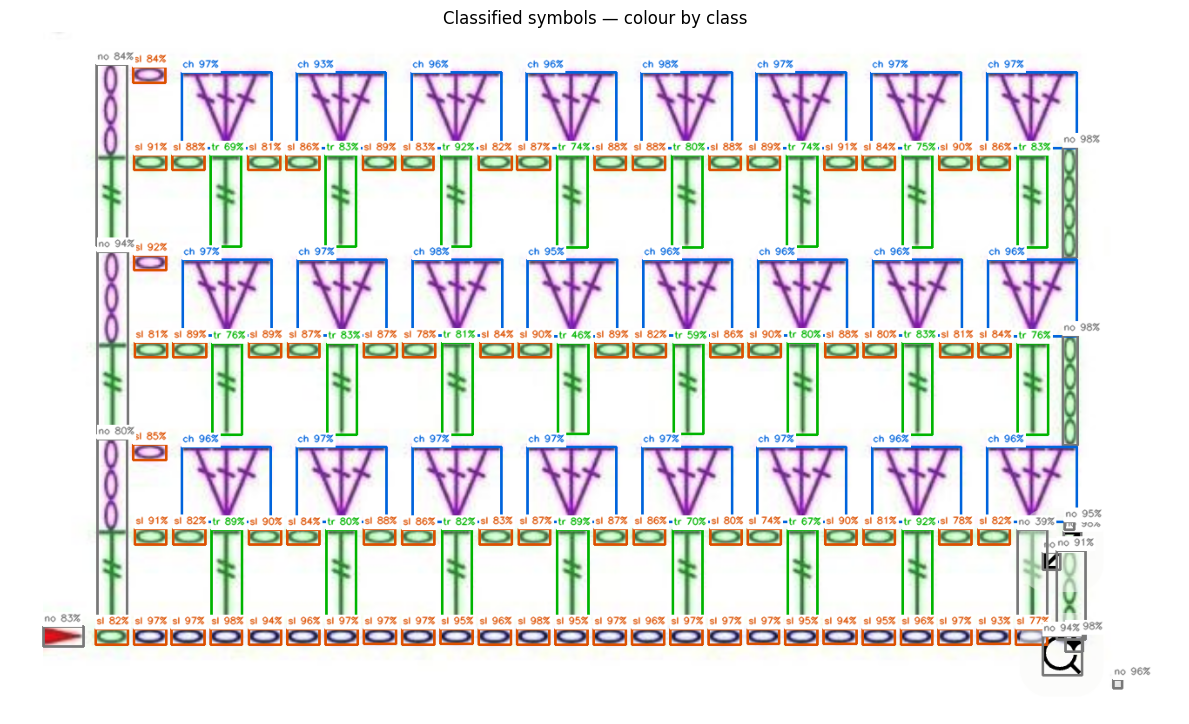

In [26]:
# Draw classification labels on the original image
# Each stitch gets a bounding box + label above it, colour-coded by class
CLASS_COLORS = {
    "treble":      (0,   180,  0),    # green
    "slip_stitch": (220,  80,  0),    # orange
    "chain":       (0,   100, 220),   # blue
    "double":      (180,   0, 180),   # purple
}
DEFAULT_COLOR = (120, 120, 120)       # grey for unknown classes

annotated = cv.cvtColor(roi_rgb.copy(), cv.COLOR_BGR2RGB)

for s in classified:
    x, y, w, h = s.bbox
    color = CLASS_COLORS.get(s.label, DEFAULT_COLOR)

    # Bounding box
    cv.rectangle(annotated, (x, y), (x + w, y + h), color, 2)

    # Short label abbreviation so it fits over small symbols
    abbrev = {
        "treble":      "tr",
        "slip_stitch": "sl",
        "chain":       "ch",
        "double":      "dc",
    }.get(s.label, s.label[:2])

    label_text = f"{abbrev} {s.confidence:.0%}"

    # White background pill so the text is readable over any image
    (tw, th), baseline = cv.getTextSize(label_text, cv.FONT_HERSHEY_SIMPLEX, 0.35, 1)
    cv.rectangle(annotated, (x, y - th - baseline - 4), (x + tw + 2, y), (255, 255, 255), -1)
    cv.putText(annotated, label_text, (x + 1, y - baseline - 2),
               cv.FONT_HERSHEY_SIMPLEX, 0.35, color, 1, cv.LINE_AA)

plt.figure(figsize=(12, 12))
plt.imshow(annotated)
plt.title("Classified symbols — colour by class")
plt.axis("off")
plt.tight_layout()
plt.show()

In [27]:
import base64

# ── Per-class stroke colours (match the annotation cell) ──────────────────
SVG_COLORS = {
    "treble":      "#00b400",
    "slip_stitch": "#dc5000",
    "chain":       "#0064dc",
    "double":      "#b400b4",
}
DEFAULT_SVG_COLOR = "#787878"


def svg_symbol(stitch, cx, cy, w, h):
    """
    Return an SVG <g> string for one stitch, scaled to fit its bounding box.
    All symbols are designed on a unit canvas then scaled to (w, h).

    Standard crochet chart symbols:
      treble      — tall stem, two diagonal yarn-over bars, T-base
      double      — medium stem, one diagonal yarn-over bar, T-base
      slip_stitch — circle (open ring)
      chain       — horizontal ellipse
    """
    color  = SVG_COLORS.get(stitch, DEFAULT_SVG_COLOR)
    sw     = max(1.0, min(w, h) * 0.07)   # stroke width scales with symbol size
    stroke = f'stroke="{color}" stroke-width="{sw:.2f}" stroke-linecap="round" fill="none"'

    if stitch == "treble":
        # Design space: width=10, height=40  (centred at 0,0)
        sx, sy = w / 10, h / 40
        return (
            f'<g transform="translate({cx},{cy})">'
            # stem
            f'<line x1="0" y1="{-h/2:.1f}" x2="0" y2="{h/2:.1f}" {stroke}/>'
            # two yarn-over bars (diagonal ticks)
            f'<line x1="{-w*0.45:.1f}" y1="{-h*0.22:.1f}" x2="{w*0.45:.1f}" y2="{-h*0.08:.1f}" {stroke}/>'
            f'<line x1="{-w*0.45:.1f}" y1="{h*0.05:.1f}"  x2="{w*0.45:.1f}" y2="{h*0.19:.1f}"  {stroke}/>'
            # T-base
            f'<line x1="{-w*0.4:.1f}" y1="{h/2:.1f}" x2="{w*0.4:.1f}" y2="{h/2:.1f}" {stroke}/>'
            f'</g>'
        )

    elif stitch == "double":
        return (
            f'<g transform="translate({cx},{cy})">'
            # stem
            f'<line x1="0" y1="{-h/2:.1f}" x2="0" y2="{h/2:.1f}" {stroke}/>'
            # one yarn-over bar
            f'<line x1="{-w*0.45:.1f}" y1="{-h*0.12:.1f}" x2="{w*0.45:.1f}" y2="{h*0.04:.1f}" {stroke}/>'
            # T-base
            f'<line x1="{-w*0.4:.1f}" y1="{h/2:.1f}" x2="{w*0.4:.1f}" y2="{h/2:.1f}" {stroke}/>'
            f'</g>'
        )

    elif stitch == "slip_stitch":
        r = min(w, h) * 0.42
        return (
            f'<g transform="translate({cx},{cy})">'
            f'<circle cx="0" cy="0" r="{r:.1f}" {stroke}/>'
            f'<circle cx="0" cy="0" r="{r*0.22:.1f}" fill="{color}" stroke="none"/>'
            f'</g>'
        )

    elif stitch == "chain":
        rx, ry = w * 0.42, h * 0.42
        return (
            f'<g transform="translate({cx},{cy})">'
            f'<ellipse cx="0" cy="0" rx="{rx:.1f}" ry="{ry:.1f}" {stroke}/>'
            f'</g>'
        )

    else:  # unknown — grey square
        return (
            f'<rect x="{cx - w/2:.1f}" y="{cy - h/2:.1f}" '
            f'width="{w}" height="{h}" fill="none" stroke="{DEFAULT_SVG_COLOR}" stroke-width="1"/>'
        )


def build_svg(classified_symbols, img_w, img_h,
              background_img=None, img_opacity=0.35):
    """
    Build a complete SVG string.

    If background_img_path is given, the PNG is embedded as a semi-transparent
    background so you can compare SVG symbols against the original scheme.
    """
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" '
        f'width="{img_w}" height="{img_h}" '
        f'viewBox="0 0 {img_w} {img_h}">'
    ]

    # Background
    if background_img is not None:
        # Convert background image to base64
        _, buffer = cv.imencode(".png", background_img)
        b64 = base64.b64encode(buffer).decode()
        parts.append(
            f'<image href="data:image/png;base64,{b64}" '
            f'x="0" y="0" width="{img_w}" height="{img_h}" '
            f'opacity="{img_opacity}"/>'
        )
    else:
        parts.append(f'<rect width="{img_w}" height="{img_h}" fill="white"/>')

    # Symbols
    parts.append('<g id="symbols">')
    for s in classified_symbols:
        x, y, w, h = s.bbox
        cx = x + w / 2
        cy = y + h / 2
        parts.append(svg_symbol(s.label, cx, cy, w, h))
    parts.append('</g>')

    # Legend
    legend_x, legend_y = 8, img_h - 10
    legend_items = list(SVG_COLORS.items())
    for i, (label, color) in enumerate(legend_items):
        lx = legend_x + i * 110
        parts.append(
            f'<rect x="{lx}" y="{legend_y - 10}" width="12" height="12" '
            f'fill="{color}" rx="2"/>'
            f'<text x="{lx + 16}" y="{legend_y}" '
            f'font-family="sans-serif" font-size="10" fill="#333">{label}</text>'
        )

    parts.append('</svg>')
    return "\n".join(parts)


print("SVG builder ready.")

SVG builder ready.


SVGs saved: scheme_overlay.svg  |  scheme_standalone.svg



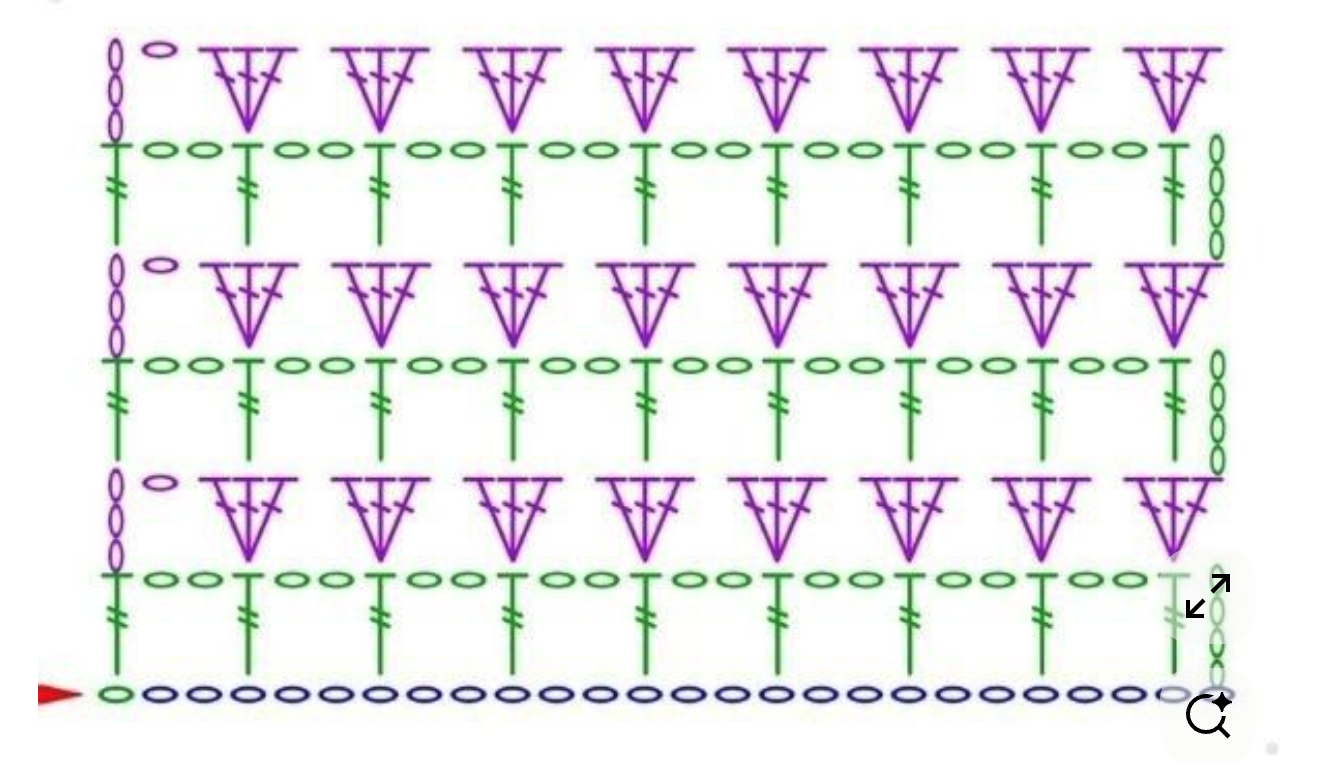

In [28]:
from IPython.display import SVG, display, HTML

img_h, img_w = roi_rgb.shape[:2]

# ── 1. Overlay: SVG symbols drawn on top of the faded original image ─────────
overlay_svg = build_svg(classified, img_w, img_h,
                        background_img=roi_rgb.copy(), img_opacity=0.35)

with open("scheme_overlay.svg", "w") as f:
    f.write(overlay_svg)

# ── 2. Standalone: same symbol positions, clean white background ──────────────
standalone_svg = build_svg(classified, img_w, img_h)

with open("scheme_standalone.svg", "w") as f:
    f.write(standalone_svg)

print("SVGs saved: scheme_overlay.svg  |  scheme_standalone.svg")

# ── Display side-by-side in the notebook ─────────────────────────────────────
display(HTML(f"""
<div style="display:flex; gap:24px; align-items:flex-start;">
  <div>
    <p style="font-family:sans-serif; font-size:13px; margin-bottom:6px;">
      <b>Overlay</b> — SVG symbols on original image
    </p>
    {overlay_svg}
  </div>
  <div>
    <p style="font-family:sans-serif; font-size:13px; margin-bottom:6px;">
      <b>Standalone</b> — clean SVG scheme
    </p>
    {standalone_svg}
  </div>
</div>
"""))

In [29]:
import os

output_dir = "data/segments/unlabeled"
os.makedirs(output_dir, exist_ok=True)

PADDING = 4  # pixels of padding around each symbol

for i, c in enumerate(contours):
    x, y, w, h = cv.boundingRect(c)
    # Add padding, clamped to image bounds
    x1 = max(x - PADDING, 0)
    y1 = max(y - PADDING, 0)
    x2 = min(x + w + PADDING, roi_rgb.shape[1])
    y2 = min(y + h + PADDING, roi_rgb.shape[0])

    crop = roi_rgb[y1:y2, x1:x2]
    crop = cv.resize(crop, (64, 64), interpolation=cv.INTER_AREA)
    cv.imwrite(f"{output_dir}/symbol_{i:04d}.png", crop)

print(f"Saved {len(contours)} crops to {output_dir}/")

Saved 137 crops to data/segments/unlabeled/
